# 01 — Dataset Exploration · Phase 2

**Phase goal:** Audit all raw rasters, align them to a common grid, analyse the target distribution, and produce `baseline_dataset.csv`.

**Deliverables from this notebook:**
- Alignment audit table — which rasters need resampling
- Target distribution analysis — confirm right skew, understand BP range
- Valid-cell mask — defines the node set for Phase 3 graph construction
- `baseline_dataset.csv` saved to `data/processed/`
- `target_transformer.pkl` saved to `data/features/`

**Run `phase2_align_rasters.py` first** for a full pipeline run. This notebook is for detailed exploration and visualization.

---

In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from pathlib import Path

# Add src/ to path
PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from wildfire_gnn.utils import load_yaml_config, set_seed
from wildfire_gnn.process.raster_io import (
    load_raster, load_raster_stack, audit_alignment, print_audit
)
from wildfire_gnn.process.target_engineering import (
    TargetTransformer, analyze_target_distribution
)

config = load_yaml_config(PROJECT_ROOT / 'configs' / 'gnn_config.yaml')
set_seed(config['training']['seed'])

RAW_DIR     = PROJECT_ROOT / config['paths']['raw_dir']
ALIGNED_DIR = PROJECT_ROOT / config['paths']['aligned_dir']
FEAT_DIR    = PROJECT_ROOT / config['paths']['features_dir']
PROC_DIR    = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR     = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Raw dir      : {RAW_DIR}')
print(f'Aligned dir  : {ALIGNED_DIR}')

Project root : d:\wildfire\spatiotemporal_wildfire_gnn
Raw dir      : d:\wildfire\spatiotemporal_wildfire_gnn\data\raw\FSim_Dataset_Greece_raw_files
Aligned dir  : d:\wildfire\spatiotemporal_wildfire_gnn\data\interim\aligned


In [3]:
raw_paths = {
    'Burn_Prob':        RAW_DIR / 'Burn_Prob.img',
    'CFL':              RAW_DIR / 'CFL.img',
    'FSP_Index':        RAW_DIR / 'FSP_Index.img',
    'Fuel_Models':      RAW_DIR / 'Fuel_Models.img',
    'Ignition_Prob':    RAW_DIR / 'Ignition_Prob.img',
    'Struct_Exp_Index': RAW_DIR / 'Struct_Exp_Index.img',
}

print('Loading raw rasters...')
stack = load_raster_stack(raw_paths, verbose=True)
audit = audit_alignment(stack, reference_name='Burn_Prob')
print_audit(audit, reference_name='Burn_Prob')

Loading raw rasters...
  ✓  Burn_Prob              shape=(7597, 7555)  valid=11,966,420  mean=0.02417
  ✓  CFL                    shape=(7597, 7555)  valid=11,965,691  mean=3.81682
  ✓  FSP_Index              shape=(7592, 7541)  valid=13,067,375  mean=1030.71204
  ✓  Fuel_Models            shape=(7932, 9039)  valid=71,697,348  mean=105.41675
  ✓  Ignition_Prob          shape=(7733, 9039)  valid=13,076,068  mean=0.26783
  ✓  Struct_Exp_Index       shape=(7592, 7541)  valid=13,067,375  mean=225.64578

  Raster Stack Alignment Audit  (reference = Burn_Prob)
  Name                     Shape            Aligned      dtype      Valid%
  ----------------------------------------------------------------------
  Burn_Prob                (7597, 7555)     ✓ OK         float32    20.85%
  CFL                      (7597, 7555)     ✓ OK         float32    20.85%
  FSP_Index                (7592, 7541)     ✗ MISMATCH   float32    22.82%
  Fuel_Models              (7932, 9039)     ✗ MISMATCH   uint8    

# Target distribution analysis


  Burn Probability Distribution (raw):
    n                      : 11,966,420
    min                    : 0.000004
    max                    : 0.250882
    mean                   : 0.024167
    median                 : 0.012004
    std                    : 0.032834
    pct_below_0.01         : 45.933487
    pct_below_0.05         : 85.960220
    pct_above_0.10         : 4.256135
    q10                    : 0.000889
    q25                    : 0.003479
    q75                    : 0.030809
    q90                    : 0.063144
    q95                    : 0.092552
    q99                    : 0.159830
    skewness               : 2.593033
  ✓  Target transform validated: mean=0.0012, std=1.0119


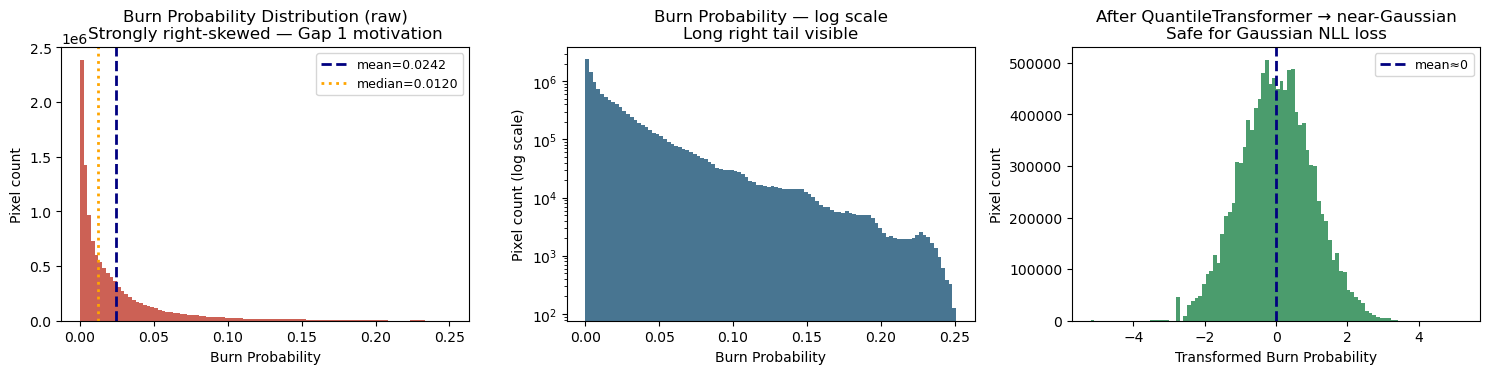


Figure saved: reports/figures/p2_burn_prob_distribution.png


In [4]:
bp   = stack['Burn_Prob']
bp_v = bp.valid_data()

stats = analyze_target_distribution(bp_v)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram of raw BP ---
ax = axes[0]
ax.hist(bp_v, bins=100, color='#C0392B', alpha=0.8, edgecolor='none')
ax.axvline(stats['mean'],   color='navy', lw=2, linestyle='--', label=f"mean={stats['mean']:.4f}")
ax.axvline(stats['median'], color='orange', lw=2, linestyle=':', label=f"median={stats['median']:.4f}")
ax.set_xlabel('Burn Probability')
ax.set_ylabel('Pixel count')
ax.set_title('Burn Probability Distribution (raw)\nStrongly right-skewed — Gap 1 motivation')
ax.legend(fontsize=9)

# --- Log-scale histogram ---
ax = axes[1]
ax.hist(bp_v, bins=100, color='#1A5276', alpha=0.8, edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('Burn Probability')
ax.set_ylabel('Pixel count (log scale)')
ax.set_title('Burn Probability — log scale\nLong right tail visible')

# --- After QuantileTransformer ---
transformer = TargetTransformer(n_quantiles=1000)
bp_t        = transformer.fit_transform(bp_v)
transformer.validate(bp_t)

ax = axes[2]
ax.hist(bp_t, bins=100, color='#1E8449', alpha=0.8, edgecolor='none')
ax.axvline(0, color='navy', lw=2, linestyle='--', label='mean≈0')
ax.set_xlabel('Transformed Burn Probability')
ax.set_ylabel('Pixel count')
ax.set_title('After QuantileTransformer → near-Gaussian\nSafe for Gaussian NLL loss')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_burn_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigure saved: reports/figures/p2_burn_prob_distribution.png')

# Visualize the Burn_Prob

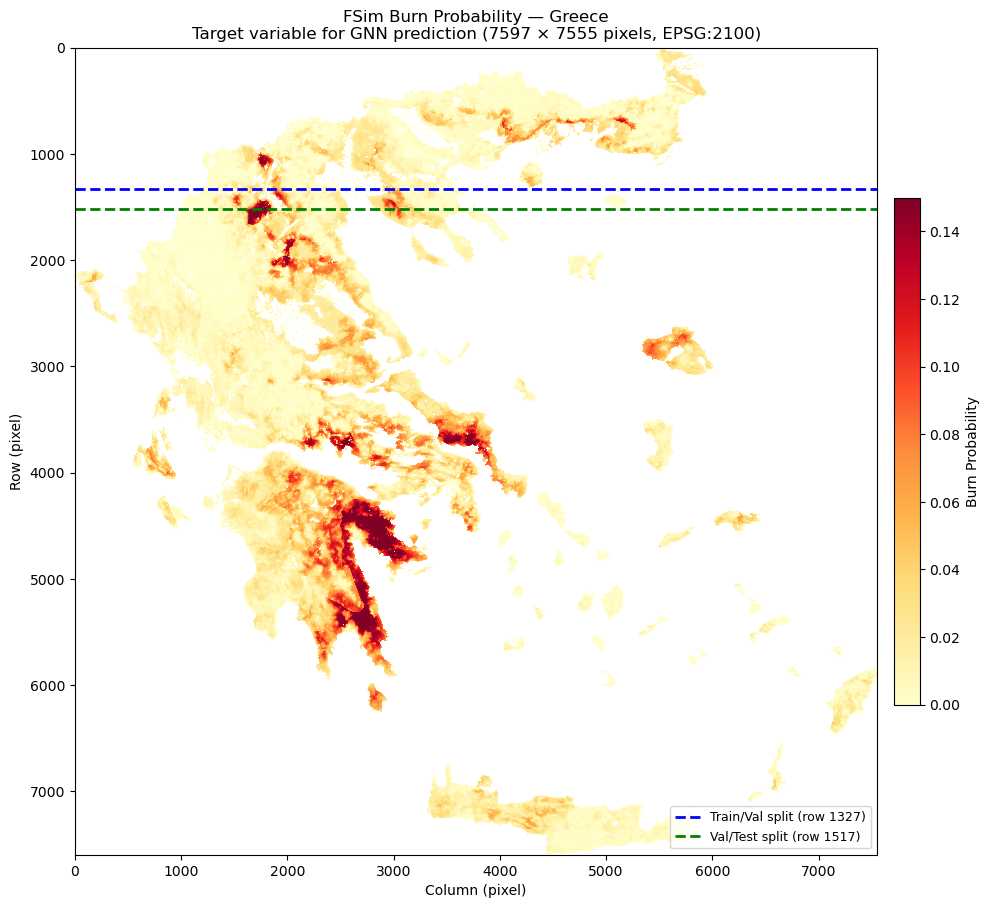


Figure saved: reports/figures/p2_burn_prob_spatial.png


In [5]:
bp_arr = bp.data   # masked array, shape (7597, 7555)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

im = ax.imshow(
    np.where(bp_arr.mask, np.nan, bp_arr.data),
    cmap='YlOrRd',
    vmin=0, vmax=0.15,
    interpolation='nearest',
)
plt.colorbar(im, ax=ax, label='Burn Probability', fraction=0.03, pad=0.02)
ax.set_title(
    'FSim Burn Probability — Greece\n'
    'Target variable for GNN prediction (7597 × 7555 pixels, EPSG:2100)',
    fontsize=12
)
ax.set_xlabel('Column (pixel)')
ax.set_ylabel('Row (pixel)')

# Add split boundary lines
train_end = config['split']['train_rows'][1]
val_end   = config['split']['val_rows'][1]
ax.axhline(train_end, color='blue',  lw=2, linestyle='--', label=f'Train/Val split (row {train_end})')
ax.axhline(val_end,   color='green', lw=2, linestyle='--', label=f'Val/Test split (row {val_end})')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_burn_prob_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigure saved: reports/figures/p2_burn_prob_spatial.png')

# Featuer raster visualization grid

In [ ]:
feature_names = ['CFL', 'FSP_Index', 'Fuel_Models', 'Ignition_Prob', 'Struct_Exp_Index']
cmaps = ['Blues', 'Greens', 'tab20', 'Oranges', 'Purples']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Plot Burn_Prob first
arr = np.where(bp.data.mask, np.nan, bp.data.data)
axes[0].imshow(arr, cmap='YlOrRd', vmin=0, vmax=0.15, interpolation='nearest')
axes[0].set_title('Burn_Prob (TARGET)\n(7597 × 7555) — REFERENCE', fontweight='bold')
axes[0].set_axis_off()

for i, (name, cmap) in enumerate(zip(feature_names, cmaps), start=1):
    ri  = stack[name]
    arr = np.where(ri.data.mask, np.nan, ri.data.data.astype(float))
    axes[i].imshow(arr, cmap=cmap, interpolation='nearest')
    aligned = '✓ ALIGNED' if audit[name]['shape_ok'] else '✗ NEEDS RESAMPLE'
    axes[i].set_title(f'{name}\n{ri.shape}  {aligned}', fontsize=10)
    axes[i].set_axis_off()

plt.suptitle('Phase 2 — Raw FSim Feature Rasters\nRed boxes = shape mismatch with reference grid',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_feature_rasters_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/p2_feature_rasters_grid.png')